In [ ]:
!pip install shap pandas numpy matplotlib

DATASET INFORMATION

Dataset shape:
(6065, 25)

Target:
CO2 Emissions(g/km)

Number of features:
23

Features:
 1. num__Engine Size(L)
 2. num__Cylinders
 3. num__Fuel Consumption Comb (L/100 km)
 4. cat__Fuel Type_Diesel
 5. cat__Fuel Type_Ethanol(E85)
 6. cat__Fuel Type_Premium Gasoline
 7. cat__Fuel Type_Regular Gasoline
 8. cat__Vehicle Class_COMPACT
 9. cat__Vehicle Class_FULL-SIZE
10. cat__Vehicle Class_MID-SIZE
11. cat__Vehicle Class_MINICOMPACT
12. cat__Vehicle Class_MINIVAN
13. cat__Vehicle Class_PICKUP TRUCK - SMALL
14. cat__Vehicle Class_PICKUP TRUCK - STANDARD
15. cat__Vehicle Class_SPECIAL PURPOSE VEHICLE
16. cat__Vehicle Class_STATION WAGON - MID-SIZE
17. cat__Vehicle Class_STATION WAGON - SMALL
18. cat__Vehicle Class_SUBCOMPACT
19. cat__Vehicle Class_SUV - SMALL
20. cat__Vehicle Class_SUV - STANDARD
21. cat__Vehicle Class_TWO-SEATER
22. cat__Vehicle Class_VAN - CARGO
23. cat__Vehicle Class_VAN - PASSENGER

X shape:
(6065, 23)

y shape:
(6065,)

DEMO DATA

Demo X shape:
(

PermutationExplainer explainer: 101it [00:11,  3.66it/s]                        



SHAP CALCULATION COMPLETE


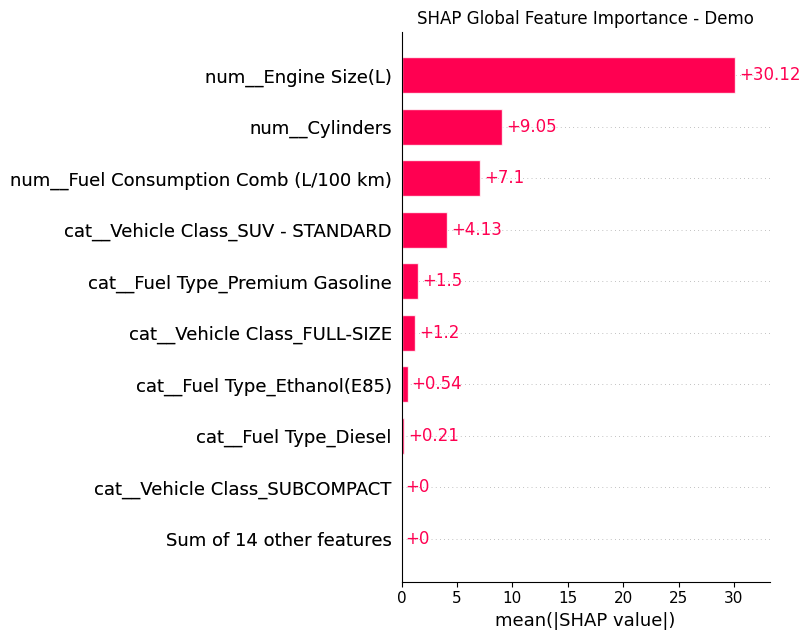

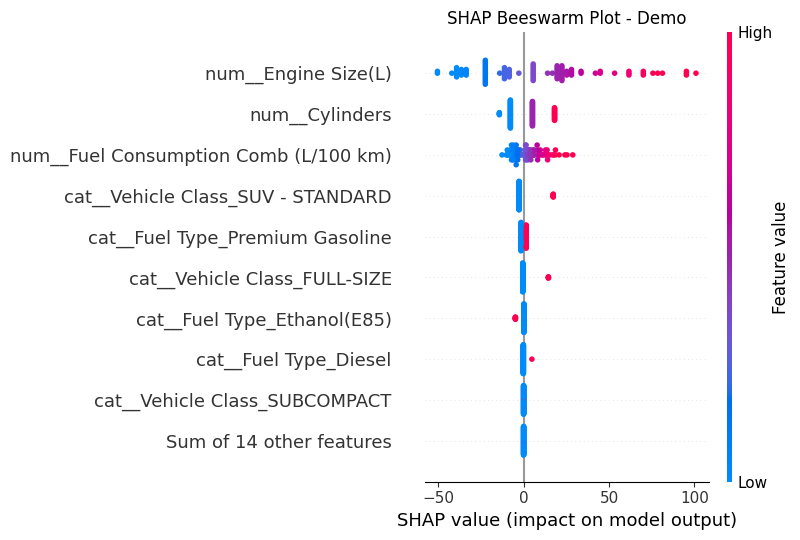

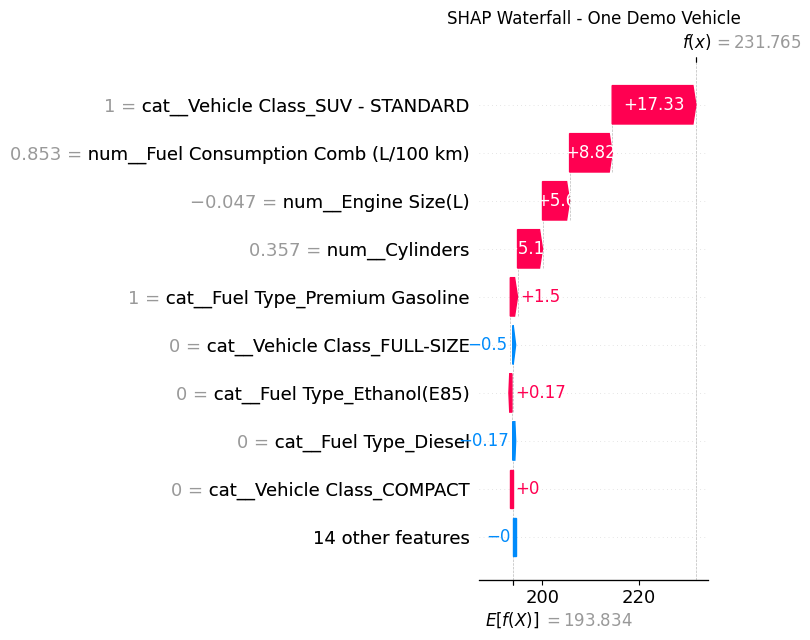

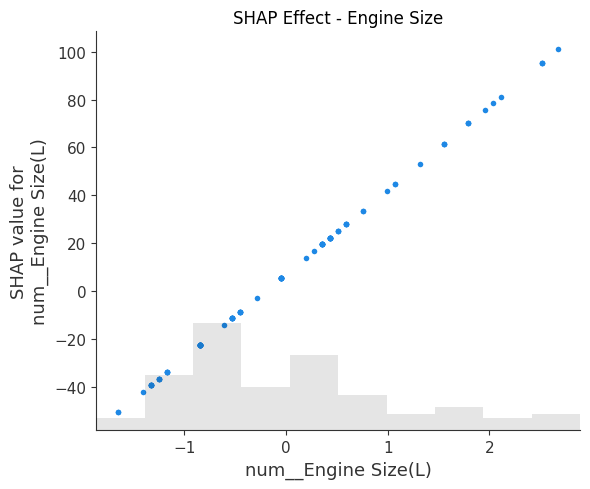

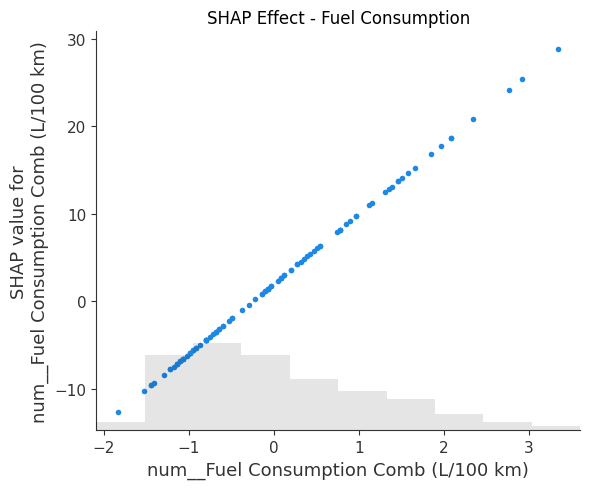

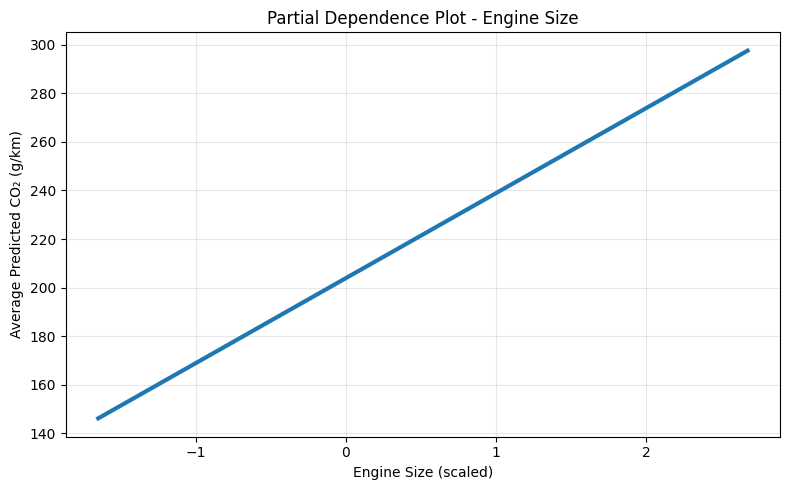

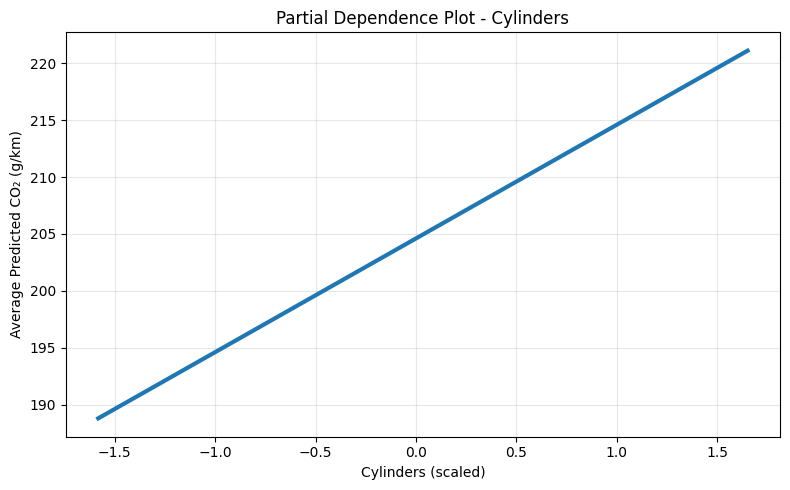

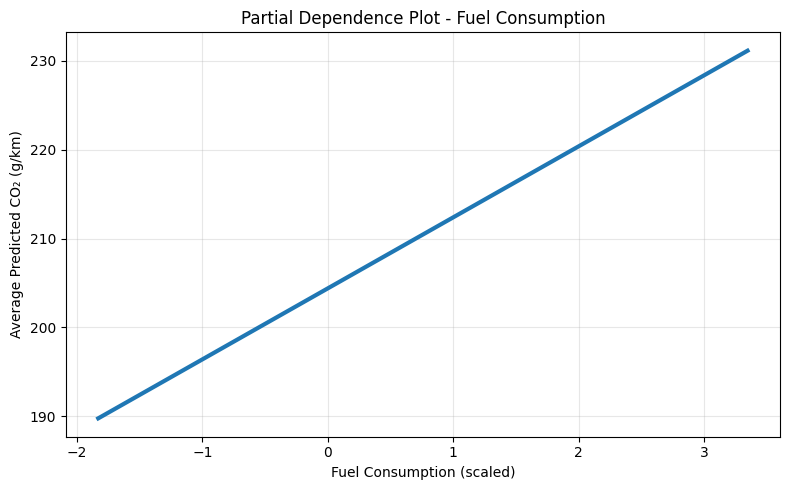

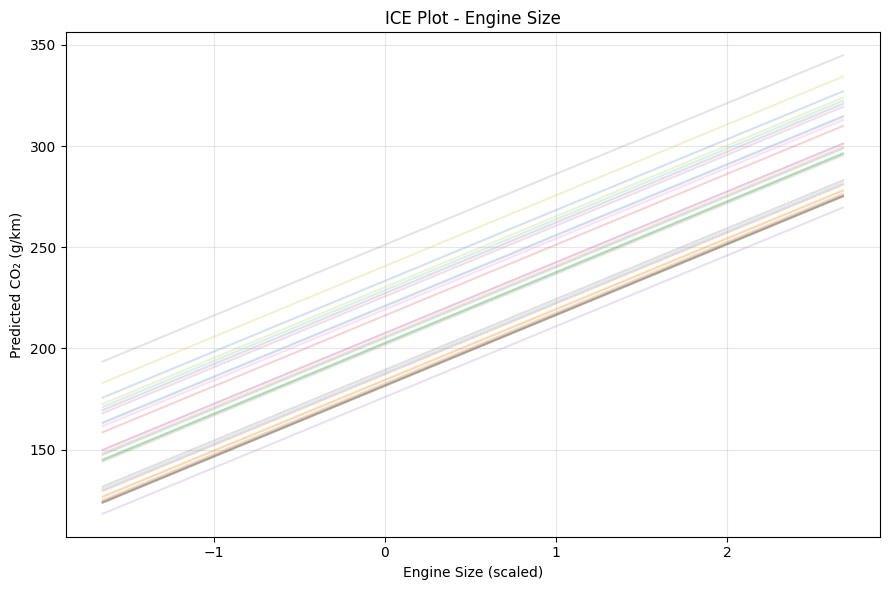

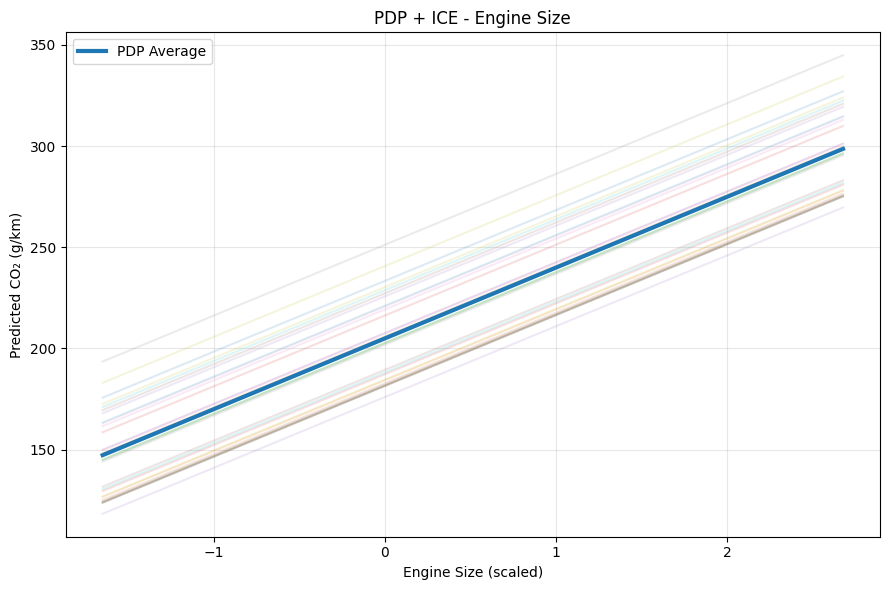

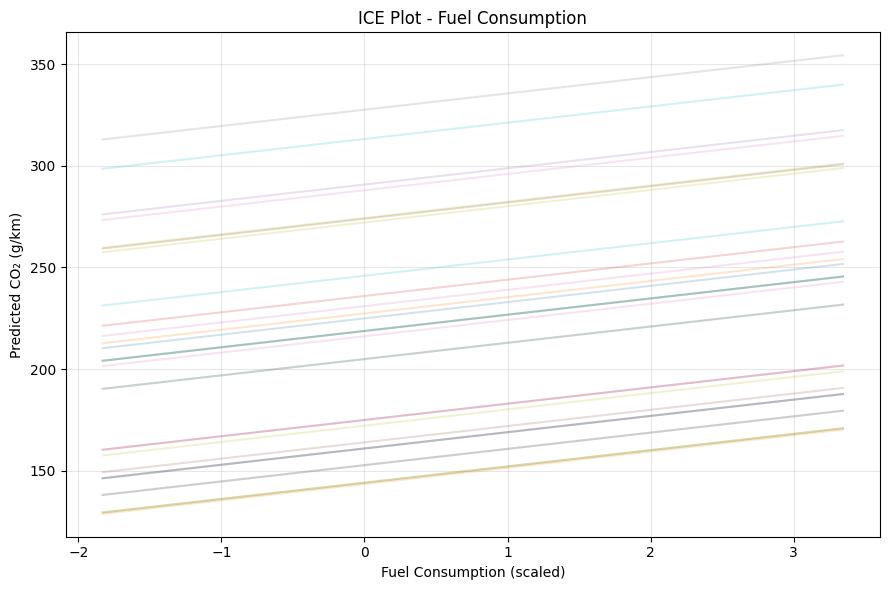

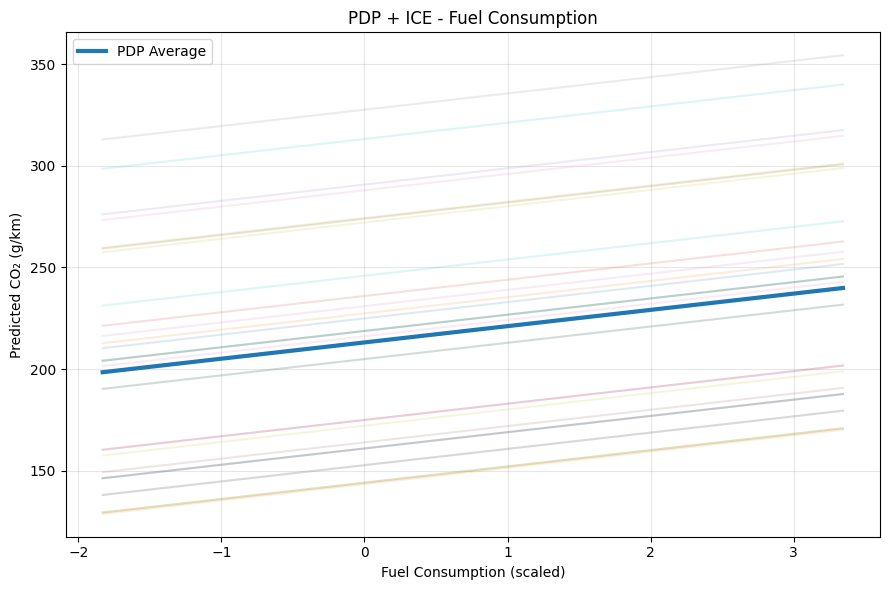

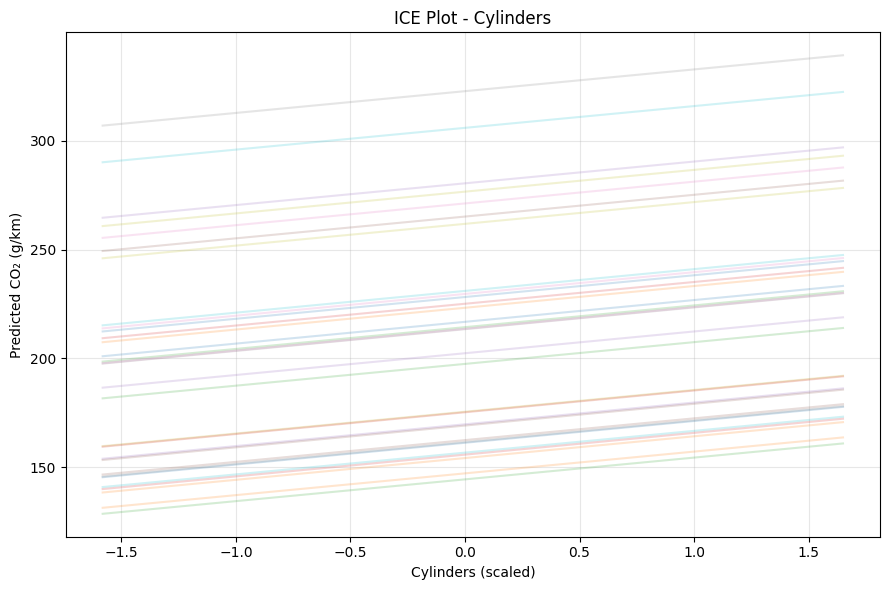

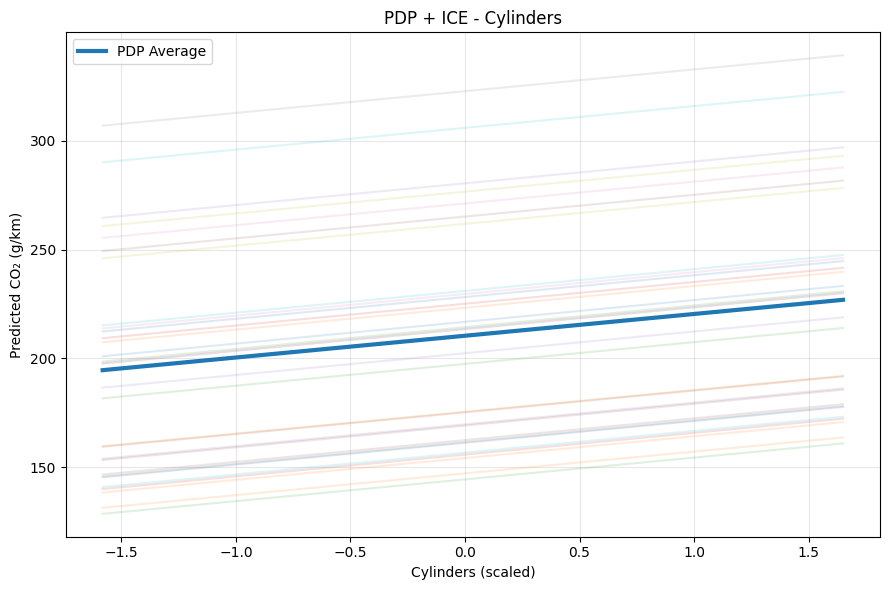



DEMO COMPLETE

SHAP:
    - Global feature importance
    - Beeswarm
    - Waterfall
    - Feature effect scatter

PDP:
    - Engine Size
    - Cylinders
    - Fuel Consumption

ICE:
    - Engine Size
    - Cylinders
    - Fuel Consumption

PDP + ICE:
    - Engine Size
    - Cylinders
    - Fuel Consumption


IMPORTANT:
This demonstration DOES NOT train an ML model.

The function:

    predict_demo()

is only a simple prediction function used to demonstrate
SHAP, PDP and ICE.

Later, when you select your best model, replace:

    predict_demo(data)

with:

    model.predict(data)

Then the same explainability workflow can be
connected to your actual model.



In [ ]:
# ============================================================
# CO2 EMISSION PROJECT
# STANDALONE SHAP + PDP + ICE DEMO
#
# IMPORTANT:
# - NO ML MODEL IS TRAINED IN THIS DEMO
# - Uses the actual FEATURES and TARGET from your dataset
# - Uses a simple mathematical prediction function only
# - Later, replace predict_demo() with your actual model.predict()
# ============================================================


# ============================================================
# 1. INSTALL IF NEEDED
# ============================================================

# Uncomment this line if SHAP is not installed:
# !pip install shap pandas numpy matplotlib


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


# ============================================================
# 3. LOAD YOUR DATASET
# ============================================================

FILE_PATH = "/content/co2_emission_final_encoded_dataset.csv"

df = pd.read_csv(FILE_PATH)


# ============================================================
# 4. DEFINE TARGET
# ============================================================

TARGET = "CO2 Emissions(g/km)"


# ============================================================
# 5. DEFINE FEATURES
# ============================================================
#
# Dataset is NOT a feature.
# It only tells us whether the row is Train,
# Validation, or Test.
# ============================================================

FEATURES = [
    column
    for column in df.columns
    if column not in [
        TARGET,
        "Dataset"
    ]
]


# ============================================================
# 6. DISPLAY DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nDataset shape:")
print(df.shape)

print("\nTarget:")
print(TARGET)

print("\nNumber of features:")
print(len(FEATURES))

print("\nFeatures:")

for i, feature in enumerate(FEATURES, start=1):
    print(f"{i:2d}. {feature}")


# ============================================================
# 7. SEPARATE X AND y
# ============================================================

X = df[FEATURES].copy()

y = df[TARGET].copy()


print("\nX shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)


# ============================================================
# 8. USE ONLY TEST DATA FOR THE DEMO
# ============================================================
#
# This follows your existing Train / Validation / Test setup.
#
# We are NOT training anything.
#
# We simply take a small sample from TEST data
# for the SHAP/PDP/ICE demonstration.
# ============================================================

if "Dataset" in df.columns:

    test_df = df[
        df["Dataset"] == "Test"
    ].copy()

else:

    test_df = df.copy()


# Number of observations used for demonstration

DEMO_SIZE = 100


if len(test_df) > DEMO_SIZE:

    demo_df = test_df.sample(
        n=DEMO_SIZE,
        random_state=42
    )

else:

    demo_df = test_df.copy()


X_demo = demo_df[FEATURES].copy()

y_demo = demo_df[TARGET].copy()


print("\n" + "=" * 70)
print("DEMO DATA")
print("=" * 70)

print("\nDemo X shape:")
print(X_demo.shape)

print("\nDemo target shape:")
print(y_demo.shape)

print("\nFirst 5 demo observations:")

print(X_demo.head())


# ============================================================
# 9. IMPORTANT FEATURES FOR VISUALIZATION
# ============================================================
#
# For a beginner-friendly PDP / ICE demonstration,
# use the three continuous features.
#
# These are actual columns from YOUR dataset.
# ============================================================

PLOT_FEATURES = [
    "num__Engine Size(L)",
    "num__Cylinders",
    "num__Fuel Consumption Comb (L/100 km)"
]


print("\n" + "=" * 70)
print("FEATURES USED FOR PDP / ICE")
print("=" * 70)

for feature in PLOT_FEATURES:
    print(feature)


# ============================================================
# 10. SIMPLE DEMONSTRATION PREDICTION FUNCTION
# ============================================================
#
# THIS IS NOT AN ML MODEL.
#
# It only creates predictions so that SHAP, PDP and ICE
# can be demonstrated.
#
# Later, you can replace this function with:
#
#     return model.predict(data)
#
# ============================================================

def predict_demo(data):

    # --------------------------------------------------------
    # Numerical features
    # --------------------------------------------------------

    engine = data[
        "num__Engine Size(L)"
    ]

    cylinders = data[
        "num__Cylinders"
    ]

    fuel_consumption = data[
        "num__Fuel Consumption Comb (L/100 km)"
    ]


    # --------------------------------------------------------
    # Simple effects
    # --------------------------------------------------------
    #
    # These coefficients are ONLY for demonstration.
    #
    # They are NOT learned from your data.
    #
    # --------------------------------------------------------

    prediction = (

        200

        + 35 * engine

        + 10 * cylinders

        + 8 * fuel_consumption

    )


    # --------------------------------------------------------
    # Add small categorical effects
    # --------------------------------------------------------

    if "cat__Fuel Type_Diesel" in data.columns:

        prediction = prediction + (
            5 * data["cat__Fuel Type_Diesel"]
        )


    if "cat__Fuel Type_Ethanol(E85)" in data.columns:

        prediction = prediction - (
            5 * data["cat__Fuel Type_Ethanol(E85)"]
        )


    if "cat__Fuel Type_Premium Gasoline" in data.columns:

        prediction = prediction + (
            3 * data["cat__Fuel Type_Premium Gasoline"]
        )


    if "cat__Vehicle Class_FULL-SIZE" in data.columns:

        prediction = prediction + (
            15 * data["cat__Vehicle Class_FULL-SIZE"]
        )


    if "cat__Vehicle Class_SUV - STANDARD" in data.columns:

        prediction = prediction + (
            20 * data["cat__Vehicle Class_SUV - STANDARD"]
        )


    return prediction


# ============================================================
# 11. CREATE DEMO PREDICTIONS
# ============================================================

demo_predictions = predict_demo(
    X_demo
)


print("\n" + "=" * 70)
print("DEMO PREDICTIONS")
print("=" * 70)

print(
    demo_predictions.head()
    if hasattr(demo_predictions, "head")
    else demo_predictions[:5]
)


# ============================================================
# 12. SHAP EXPLAINER
# ============================================================
#
# We use SHAP's model-agnostic Explainer.
#
# No ML model is being trained.
# SHAP simply calls our predict_demo() function.
# ============================================================

BACKGROUND_SIZE = min(
    30,
    len(X_demo)
)


background_data = X_demo.sample(
    n=BACKGROUND_SIZE,
    random_state=42
)


explainer = shap.Explainer(
    predict_demo,
    background_data
)


shap_values = explainer(
    X_demo
)


print("\n" + "=" * 70)
print("SHAP CALCULATION COMPLETE")
print("=" * 70)


# ============================================================
# 13. SHAP PLOT 1
# GLOBAL FEATURE IMPORTANCE
# ============================================================

plt.figure(
    figsize=(8, 6)
)

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Global Feature Importance - Demo"
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. SHAP PLOT 2
# BEESWARM
# ============================================================

plt.figure(
    figsize=(9, 6)
)

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Beeswarm Plot - Demo"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. SHAP PLOT 3
# WATERFALL FOR ONE OBSERVATION
# ============================================================

shap.plots.waterfall(
    shap_values[0],
    max_display=10,
    show=False
)

plt.title(
    "SHAP Waterfall - One Demo Vehicle"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. SHAP PLOT 4
# ENGINE SIZE SHAP EFFECT
# ============================================================

shap.plots.scatter(
    shap_values[
        :,
        "num__Engine Size(L)"
    ],
    show=False
)

plt.title(
    "SHAP Effect - Engine Size"
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. SHAP PLOT 5
# FUEL CONSUMPTION SHAP EFFECT
# ============================================================

shap.plots.scatter(
    shap_values[
        :,
        "num__Fuel Consumption Comb (L/100 km)"
    ],
    show=False
)

plt.title(
    "SHAP Effect - Fuel Consumption"
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. MANUAL PDP FUNCTION
# ============================================================
#
# Since we are NOT using an ML estimator,
# we calculate PDP manually.
#
# PDP idea:
#
# Change ONE feature.
# Keep the other observations.
# Calculate predictions.
# Average the predictions.
# ============================================================

def calculate_pdp(
    data,
    feature,
    grid_values
):

    pdp_values = []


    for value in grid_values:

        modified_data = data.copy()

        modified_data[
            feature
        ] = value


        predictions = predict_demo(
            modified_data
        )


        average_prediction = np.mean(
            predictions
        )


        pdp_values.append(
            average_prediction
        )


    return np.array(
        pdp_values
    )


# ============================================================
# 19. PDP - ENGINE SIZE
# ============================================================

engine_min = X_demo[
    "num__Engine Size(L)"
].min()

engine_max = X_demo[
    "num__Engine Size(L)"
].max()


engine_grid = np.linspace(
    engine_min,
    engine_max,
    50
)


engine_pdp = calculate_pdp(
    X_demo,
    "num__Engine Size(L)",
    engine_grid
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    engine_grid,
    engine_pdp,
    linewidth=3
)

plt.xlabel(
    "Engine Size (scaled)"
)

plt.ylabel(
    "Average Predicted CO₂ (g/km)"
)

plt.title(
    "Partial Dependence Plot - Engine Size"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. PDP - CYLINDERS
# ============================================================

cylinder_min = X_demo[
    "num__Cylinders"
].min()

cylinder_max = X_demo[
    "num__Cylinders"
].max()


cylinder_grid = np.linspace(
    cylinder_min,
    cylinder_max,
    30
)


cylinder_pdp = calculate_pdp(
    X_demo,
    "num__Cylinders",
    cylinder_grid
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    cylinder_grid,
    cylinder_pdp,
    linewidth=3
)

plt.xlabel(
    "Cylinders (scaled)"
)

plt.ylabel(
    "Average Predicted CO₂ (g/km)"
)

plt.title(
    "Partial Dependence Plot - Cylinders"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. PDP - FUEL CONSUMPTION
# ============================================================

fuel_min = X_demo[
    "num__Fuel Consumption Comb (L/100 km)"
].min()

fuel_max = X_demo[
    "num__Fuel Consumption Comb (L/100 km)"
].max()


fuel_grid = np.linspace(
    fuel_min,
    fuel_max,
    50
)


fuel_pdp = calculate_pdp(
    X_demo,
    "num__Fuel Consumption Comb (L/100 km)",
    fuel_grid
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    fuel_grid,
    fuel_pdp,
    linewidth=3
)

plt.xlabel(
    "Fuel Consumption (scaled)"
)

plt.ylabel(
    "Average Predicted CO₂ (g/km)"
)

plt.title(
    "Partial Dependence Plot - Fuel Consumption"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. ICE FUNCTION
# ============================================================
#
# ICE:
#
# Instead of averaging all observations,
# calculate a prediction curve for each observation.
# ============================================================

def calculate_ice(
    data,
    feature,
    grid_values,
    number_of_samples=30
):

    sample = data.iloc[
        :number_of_samples
    ].copy()


    all_curves = []


    for index, row in sample.iterrows():

        row_predictions = []


        for value in grid_values:

            modified_row = row.copy()

            modified_row[
                feature
            ] = value


            modified_df = pd.DataFrame(
                [modified_row]
            )


            prediction = predict_demo(
                modified_df
            ).iloc[0]


            row_predictions.append(
                prediction
            )


        all_curves.append(
            row_predictions
        )


    return np.array(
        all_curves
    )


# ============================================================
# 23. ICE - ENGINE SIZE
# ============================================================

engine_ice = calculate_ice(
    X_demo,
    "num__Engine Size(L)",
    engine_grid,
    number_of_samples=30
)


plt.figure(
    figsize=(9, 6)
)


for curve in engine_ice:

    plt.plot(
        engine_grid,
        curve,
        alpha=0.20
    )


plt.xlabel(
    "Engine Size (scaled)"
)

plt.ylabel(
    "Predicted CO₂ (g/km)"
)

plt.title(
    "ICE Plot - Engine Size"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. PDP + ICE - ENGINE SIZE
# ============================================================

plt.figure(
    figsize=(9, 6)
)


# ICE curves

for curve in engine_ice:

    plt.plot(
        engine_grid,
        curve,
        alpha=0.15
    )


# PDP average

engine_average = engine_ice.mean(
    axis=0
)


plt.plot(
    engine_grid,
    engine_average,
    linewidth=3,
    label="PDP Average"
)


plt.xlabel(
    "Engine Size (scaled)"
)

plt.ylabel(
    "Predicted CO₂ (g/km)"
)

plt.title(
    "PDP + ICE - Engine Size"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 25. ICE - FUEL CONSUMPTION
# ============================================================

fuel_ice = calculate_ice(
    X_demo,
    "num__Fuel Consumption Comb (L/100 km)",
    fuel_grid,
    number_of_samples=30
)


plt.figure(
    figsize=(9, 6)
)


for curve in fuel_ice:

    plt.plot(
        fuel_grid,
        curve,
        alpha=0.20
    )


plt.xlabel(
    "Fuel Consumption (scaled)"
)

plt.ylabel(
    "Predicted CO₂ (g/km)"
)

plt.title(
    "ICE Plot - Fuel Consumption"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 26. PDP + ICE - FUEL CONSUMPTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


for curve in fuel_ice:

    plt.plot(
        fuel_grid,
        curve,
        alpha=0.15
    )


fuel_average = fuel_ice.mean(
    axis=0
)


plt.plot(
    fuel_grid,
    fuel_average,
    linewidth=3,
    label="PDP Average"
)


plt.xlabel(
    "Fuel Consumption (scaled)"
)

plt.ylabel(
    "Predicted CO₂ (g/km)"
)

plt.title(
    "PDP + ICE - Fuel Consumption"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 27. ICE - CYLINDERS
# ============================================================

cylinder_ice = calculate_ice(
    X_demo,
    "num__Cylinders",
    cylinder_grid,
    number_of_samples=30
)


plt.figure(
    figsize=(9, 6)
)


for curve in cylinder_ice:

    plt.plot(
        cylinder_grid,
        curve,
        alpha=0.20
    )


plt.xlabel(
    "Cylinders (scaled)"
)

plt.ylabel(
    "Predicted CO₂ (g/km)"
)

plt.title(
    "ICE Plot - Cylinders"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 28. PDP + ICE - CYLINDERS
# ============================================================

plt.figure(
    figsize=(9, 6)
)


for curve in cylinder_ice:

    plt.plot(
        cylinder_grid,
        curve,
        alpha=0.15
    )


cylinder_average = cylinder_ice.mean(
    axis=0
)


plt.plot(
    cylinder_grid,
    cylinder_average,
    linewidth=3,
    label="PDP Average"
)


plt.xlabel(
    "Cylinders (scaled)"
)

plt.ylabel(
    "Predicted CO₂ (g/km)"
)

plt.title(
    "PDP + ICE - Cylinders"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 29. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("DEMO COMPLETE")
print("=" * 70)

print("""
SHAP:
    - Global feature importance
    - Beeswarm
    - Waterfall
    - Feature effect scatter

PDP:
    - Engine Size
    - Cylinders
    - Fuel Consumption

ICE:
    - Engine Size
    - Cylinders
    - Fuel Consumption

PDP + ICE:
    - Engine Size
    - Cylinders
    - Fuel Consumption


IMPORTANT:
This demonstration DOES NOT train an ML model.

The function:

    predict_demo()

is only a simple prediction function used to demonstrate
SHAP, PDP and ICE.

Later, when you select your best model, replace:

    predict_demo(data)

with:

    model.predict(data)

Then the same explainability workflow can be
connected to your actual model.
""")